## DATASET DESCRIPTION


The dataset used in this project contains reported crime incidents in Los Angeles from **2020 to 2024**. The dataset was obtained from the :contentReference[oaicite:0]{index=0} and includes **over 1 million crime records**.

Each row in the dataset represents a single reported crime incident and contains information related to:

- Date and time of occurrence
- Geographic area
- Crime code and crime description
- Victim demographics
- Weapon information
- Location coordinates
- Premise description
- Investigation status

The dataset spans multiple years, enabling analysis of temporal trends, geographic crime distribution, and evolving crime patterns over time.

In [2]:
import pandas as pd

##  DATA CLEANING 

In [3]:
df = pd.read_csv('/Users/ugne_kam/Desktop/Crime_Data_from_2020_to_2024.csv')
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868


- Checking missing values to decide which columns should be dropped or filled.

In [4]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64

- Dropping collumns that are not useful:
    - Crm Cd 2–4 had too many missing values
    - Cross Street was mostly missing
    - Weapon Used Cd was redundant because you kept Weapon Desc
    - Status was redundant because you kept Status Desc

In [5]:
df = df.drop(columns=[
    'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4',
    'Cross Street', 'Mocodes',
    'Weapon Used Cd', 'Status'
])

- Standardizing column names : removing spaces, making everything lowercase, replacing spaces with underscores.

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

- Creating a new hour column for time-based analysis, extracting first two digits as hour.

In [7]:
df['time_occ'] = df['time_occ'].astype(str).str.zfill(4)
df['hour'] = df['time_occ'].str[:2].astype(int)

- Replacing missing values with meaningful labels.
    - Missing weapon_desc becomes "None" because many crimes do not involve weapons.
    - Missing vict_descent becomes "Unknown".
    - Missing vict_sex becomes "Unknown".

In [8]:
df['weapon_desc'] = df['weapon_desc'].fillna('None')
df['vict_descent'] = df['vict_descent'].fillna('Unknown')
df['vict_sex'] = df['vict_sex'].fillna('Unknown')

In [9]:
df

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,vict_descent,premis_cd,premis_desc,weapon_desc,status_desc,crm_cd_1,location,lat,lon,hour
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,0845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,H,501.0,SINGLE FAMILY DWELLING,None,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,8
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,H,102.0,SIDEWALK,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,18
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,W,501.0,SINGLE FAMILY DWELLING,None,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,12
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,A,101.0,STREET,None,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,13
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,H,103.0,ALLEY,None,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,Unknown,101.0,STREET,None,Invest Cont,510.0,4000 W 23RD ST,34.0362,-118.3284,14
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,0100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,X,503.0,HOTEL,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,745.0,1300 W SUNSET BL,34.0685,-118.2460,1
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,B,210.0,RESTAURANT/FAST FOOD,None,Invest Cont,341.0,1700 ALBION ST,34.0675,-118.2240,23
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,W,102.0,SIDEWALK,STICK,Invest Cont,230.0,FLOWER ST,34.0215,-118.2868,15


## DATA PREPROCESSING

- CRIME SIMPLIFICATION

The original dataset contained more than 140 unique crime descriptions in the crm_cd_desc column. These categories were too fragmented for meaningful visualization and analysis. Many crime types had very small numbers of observations, making comparisons difficult.

To address this issue, the crime descriptions were grouped into broader analytical categories using a custom preprocessing function.The order of the classification rules was important because some descriptions contained overlapping keywords. Vehicle-related and fraud-related crimes were checked before general theft-related crimes to reduce misclassification.

In [10]:
df['crm_cd_desc'].unique()

<ArrowStringArray>
[                                       'THEFT OF IDENTITY',
           'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT',
      'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)',
          'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)',
 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)',
                                         'VEHICLE - STOLEN',
                                                 'BURGLARY',
                                    'BURGLARY FROM VEHICLE',
                       'THEFT PLAIN - PETTY ($950 & UNDER)',
                        'INTIMATE PARTNER - SIMPLE ASSAULT',
 ...
 'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM',
                                                   'BIGAMY',
                                      'FAILURE TO DISPERSE',
       'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
             'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)',
                           'BLOCKING DOOR INDUCTION CENTER',


In [11]:
df['crm_cd_desc'].nunique()

140

In [ ]:
def simplify_crime(crime_desc):

    x = str(crime_desc).lower()

    vehicle_keywords = [
        'vehicle', 'auto', 'carjacking',
        'grand theft auto'
    ]

    fraud_keywords = [
        'fraud', 'identity', 'credit',
        'forgery', 'embezzle', 'counterfeit'
    ]

    theft_keywords = [
        'theft', 'shoplift',
        'pickpocket', 'purse snatch',
        'stolen'
    ]

    burglary_keywords = [
        'burglary', 'break-in'
    ]

    vandalism_keywords = [
        'vandalism', 'graffiti', 'damage'
    ]

    assault_keywords = [
        'assault', 'battery',
        'domestic violence', 'aggravated'
    ]

    robbery_keywords = [
        'robbery', 'mugging'
    ]

    homicide_keywords = [
        'homicide', 'manslaughter', 'murder'
    ]

    weapon_keywords = [
        'weapon', 'firearm',
        'gun', 'rifle', 'knife'
    ]

    sex_keywords = [
        'rape', 'sexual',
        'molest', 'indecent exposure'
    ]

    trespass_keywords = [
        'trespass'
    ]

    disorder_keywords = [
        'drunk', 'disorderly',
        'disturbing the peace', 'loitering'
    ]

   
    # Matching
    if any(word in x for word in vehicle_keywords):
        return 'Vehicle Crime'

    elif any(word in x for word in fraud_keywords):
        return 'Fraud'

    elif any(word in x for word in theft_keywords):
        return 'Theft'

    elif any(word in x for word in burglary_keywords):
        return 'Burglary'

    elif any(word in x for word in assault_keywords):
        return 'Assault'

    elif any(word in x for word in robbery_keywords):
        return 'Robbery'

    elif any(word in x for word in homicide_keywords):
        return 'Homicide'

    elif any(word in x for word in vandalism_keywords):
        return 'Vandalism'

    elif 'arson' in x:
        return 'Arson'

    elif any(word in x for word in weapon_keywords):
        return 'Weapon Violation'

    elif any(word in x for word in sex_keywords):
        return 'Sex Crime'

    elif any(word in x for word in trespass_keywords):
        return 'Trespassing'

    elif any(word in x for word in disorder_keywords):
        return 'Public Disorder'

    else:
        return 'Other'
    
df['crime_category'] = df['crm_cd_desc'].apply(simplify_crime)

df['crime_category'].value_counts()

crime_category
Vehicle Crime       266391
Assault             203513
Theft               150658
Vandalism            86311
Fraud                70919
Burglary             61798
Other                58436
Robbery              37145
Weapon Violation     36548
Trespassing          18090
Sex Crime             7124
Arson                 2461
Homicide              1575
Public Disorder       1547
Name: count, dtype: int64

/var/folders/5n/254x1_w97dsddhwddlsf51fr0000gn/T/ipykernel_68374/2470728877.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


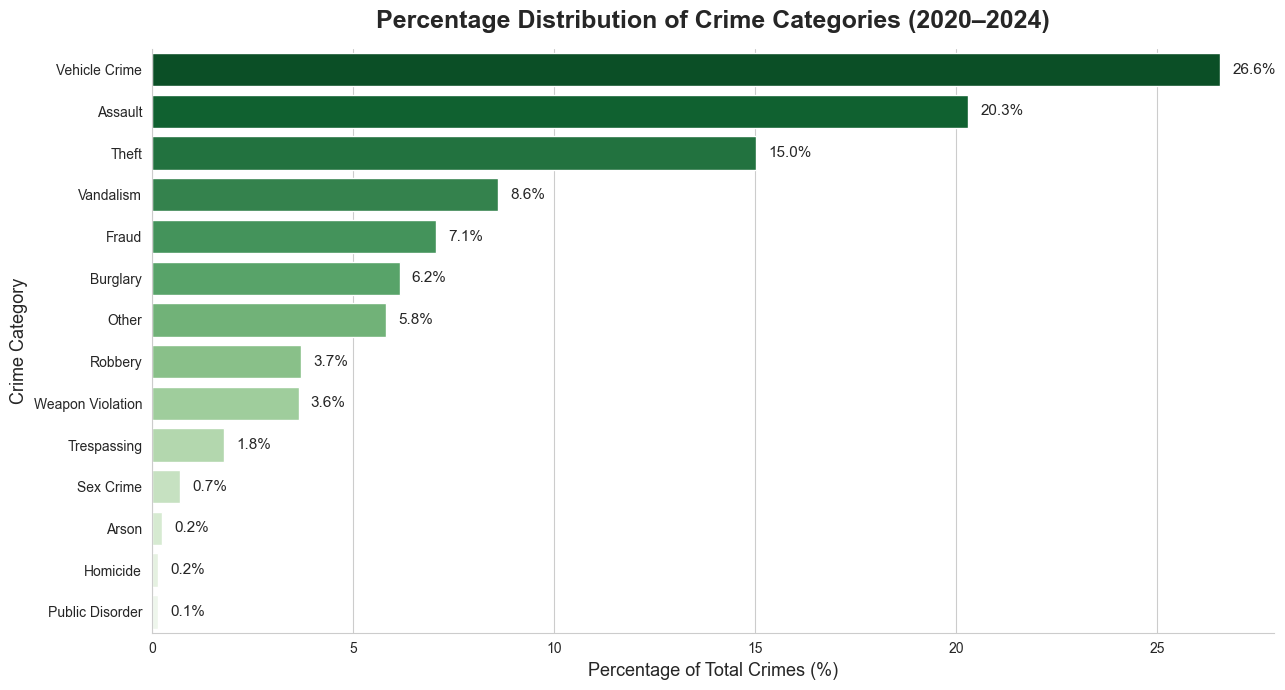

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Percentage calculation
crime_percent = (
    df['crime_category']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sns.set_style("whitegrid")
plt.figure(figsize=(13,7))

colors = sns.color_palette("Greens_r", len(crime_percent))

ax = sns.barplot(
    x=crime_percent.values,
    y=crime_percent.index,
    palette=colors
)

for i, v in enumerate(crime_percent.values):
    ax.text(
        v + 0.3,
        i,
        f"{v:.1f}%",
        va='center',
        fontsize=11
    )

plt.title(
    'Percentage Distribution of Crime Categories (2020–2024)',
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel(
    'Percentage of Total Crimes (%)',
    fontsize=13
)

plt.ylabel(
    'Crime Category',
    fontsize=13
)

sns.despine()

plt.tight_layout()
plt.show()

The chart shows that Vehicle Crime was the most common crime category in Los Angeles between 2020 and 2024, followed by Assault and Theft. Together, these categories accounted for the majority of recorded crimes in the dataset.

Categories such as Vandalism, Fraud, and Burglary were also relatively common, while Homicide, Arson, and Public Disorder were rare. Simplifying over 140 detailed crime descriptions into broader categories made the data easier to analyze and visualize.

## COVID ANALYSIS

In [57]:
df['covid_period'] = df['date_occ'].apply(
    lambda x: 'Pandemic' if x.year in [2020, 2021]
    else 'Post-Pandemic'
)

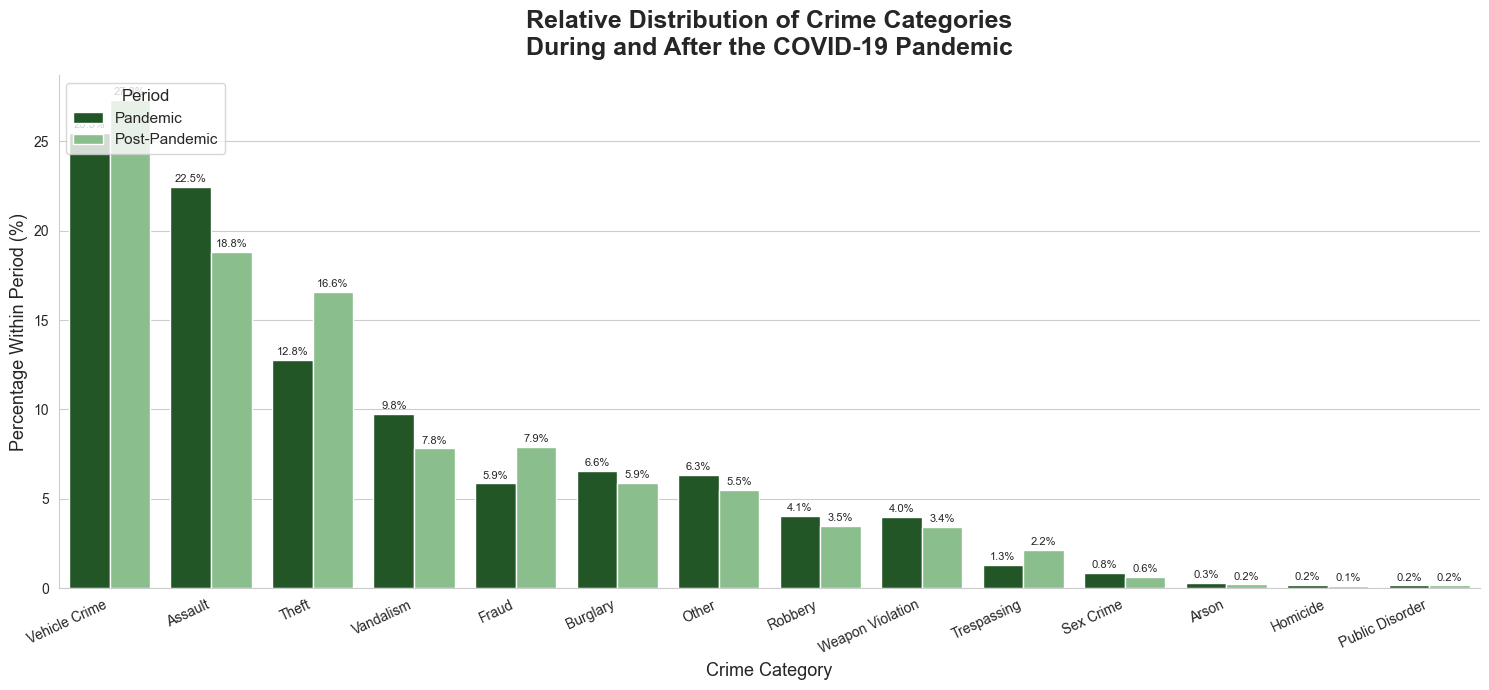

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# normalized percentages by period
covid_percent = (
    pd.crosstab(
        df['crime_category'],
        df['covid_period'],
        normalize='columns'
    ) * 100
)

# long format
plot_df = covid_percent.reset_index().melt(
    id_vars='crime_category',
    var_name='Period',
    value_name='Percentage'
)

# sorting by frequency
order = (
    df['crime_category']
    .value_counts(normalize=True)
    .sort_values(ascending=False)
    .index
)

sns.set_style("whitegrid")

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=plot_df,
    x='crime_category',
    y='Percentage',
    hue='Period',
    order=order,
    palette=['#1B5E20', '#81C784']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=2
    )

plt.title(
    'Relative Distribution of Crime Categories\nDuring and After the COVID-19 Pandemic',
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel('Crime Category', fontsize=13)
plt.ylabel('Percentage Within Period (%)', fontsize=13)

plt.xticks(rotation=25, ha='right')

plt.legend(
    title='Period',
    fontsize=11,
    title_fontsize=12,
    loc='upper left'
)

sns.despine()
plt.tight_layout()
plt.show()

The chart shows that crime patterns changed after the COVID-19 pandemic. Vehicle Crime remained the most common category and increased slightly post-pandemic, while Theft also became more frequent. In contrast, Assault and Vandalism decreased proportionally. Overall, the results suggest a shift toward more property- and vehicle-related crimes after the pandemic.

## DAY AND NIGHT ANALYSIS

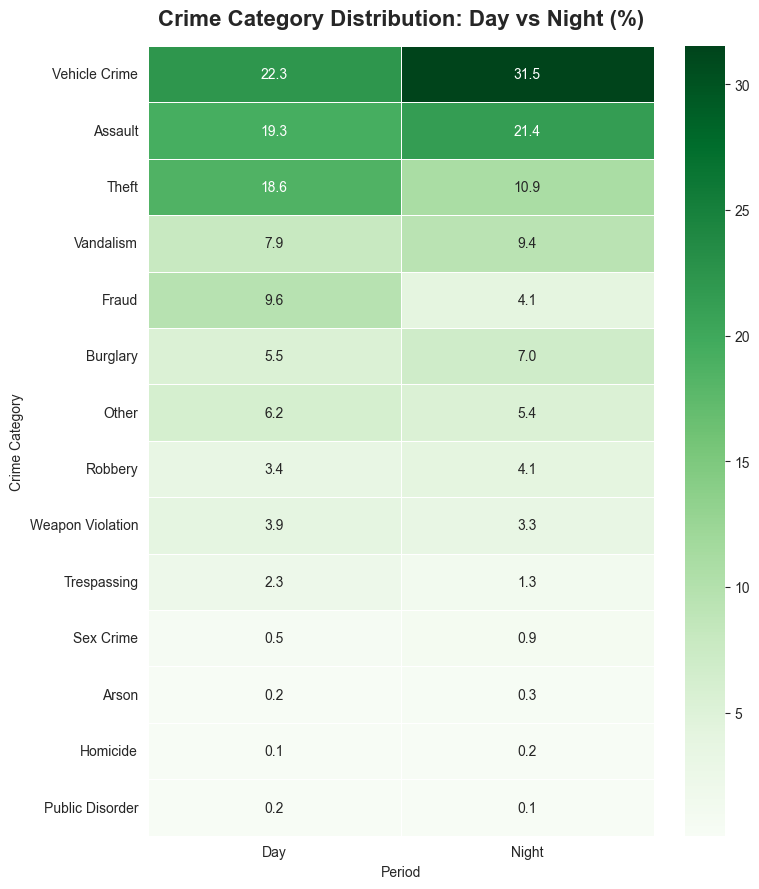

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#day/night feature
df['day_period'] = df['hour'].apply(
    lambda x: 'Day' if 6 <= x < 18 else 'Night'
)

# percentage distribution
heatmap_data = (
    pd.crosstab(
        df['crime_category'],
        df['day_period'],
        normalize='columns'
    ) * 100
)

order = df['crime_category'].value_counts().index
heatmap_data = heatmap_data.loc[order]

plt.figure(figsize=(8, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white'
)

plt.title(
    'Crime Category Distribution: Day vs Night (%)',
    fontsize=16,
    weight='bold',
    pad=15
)

plt.xlabel('Period')
plt.ylabel('Crime Category')

plt.tight_layout()
plt.show()

The heatmap reveals noticeable differences between daytime and nighttime crime patterns. Vehicle Crime and Assault were more common during the night, while Theft and Fraud had higher proportions during the day. These results suggest that property and financial crimes are more associated with daytime activity, whereas vehicle-related and violent crimes become more prominent at night.

In [14]:
# Fix dates
df['date_occ'] = pd.to_datetime(df['date_occ'])
df['date_rptd'] = pd.to_datetime(df['date_rptd'])

# Fix types
df['premis_cd'] = df['premis_cd'].astype('Int64')
df['crm_cd_1'] = df['crm_cd_1'].astype('Int64')

# Remove invalid coordinates
df = df[(df['lat'] != 0) & (df['lon'] != 0)]

# Fix age
df = df[(df['vict_age'] >= 0) & (df['vict_age'] <= 100)]

/var/folders/5n/254x1_w97dsddhwddlsf51fr0000gn/T/ipykernel_68374/3055555077.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_occ'] = pd.to_datetime(df['date_occ'])
/var/folders/5n/254x1_w97dsddhwddlsf51fr0000gn/T/ipykernel_68374/3055555077.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_rptd'] = pd.to_datetime(df['date_rptd'])


** EXPLORATORY DATA ANALYSIS **

In [15]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 1002516 entries, 0 to 1004893
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   dr_no           1002516 non-null  int64         
 1   date_rptd       1002516 non-null  datetime64[us]
 2   date_occ        1002516 non-null  datetime64[us]
 3   time_occ        1002516 non-null  str           
 4   area            1002516 non-null  int64         
 5   area_name       1002516 non-null  str           
 6   rpt_dist_no     1002516 non-null  int64         
 7   part_1-2        1002516 non-null  int64         
 8   crm_cd          1002516 non-null  int64         
 9   crm_cd_desc     1002516 non-null  str           
 10  vict_age        1002516 non-null  int64         
 11  vict_sex        1002516 non-null  str           
 12  vict_descent    1002516 non-null  str           
 13  premis_cd       1002500 non-null  Int64         
 14  premis_desc     1001928 non-null  

,dr_no,date_rptd,date_occ,area,rpt_dist_no,part_1-2,crm_cd,vict_age,premis_cd,crm_cd_1,lat,lon,hour
count,1.002516e+06,1002516,1002516,1.002516e+06,1.002516e+06,1.002516e+06,1.002516e+06,1.002516e+06,1002500.0,1002505.0,1.002516e+06,1.002516e+06,1.002516e+06
mean,2.202451e+08,2022-05-26 18:31:16.379827,2022-05-14 16:08:59.678967,1.069208e+01,1.115666e+03,1.399602e+00,4.997474e+02,2.891888e+01,305.508682,499.507764,3.407415e+01,-1.183547e+02,1.322200e+01
min,8.170000e+02,2020-01-01 00:00:00,2020-01-01 00:00:00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,0.000000e+00,101.0,110.0,3.370590e+01,-1.186676e+02,0.000000e+00
25%,2.106178e+08,2021-04-22 00:00:00,2021-04-07 00:00:00,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,101.0,331.0,3.401537e+01,-1.184309e+02,9.000000e+00
50%,2.209174e+08,2022-06-09 00:00:00,2022-05-28 00:00:00,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,203.0,442.0,3.405920e+01,-1.183230e+02,1.400000e+01
75%,2.311109e+08,2023-07-05 00:00:00,2023-06-23 00:00:00,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,501.0,626.0,3.416490e+01,-1.182740e+02,1.900000e+01
max,2.521040e+08,2025-03-28 00:00:00,2024-12-30 00:00:00,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,9.900000e+01,976.0,956.0,3.433430e+01,-1.181554e+02,2.300000e+01
std,1.318986e+07,NaN,NaN,6.110094e+00,6.111425e+02,4.898167e-01,2.051240e+02,2.199132e+01,219.287327,204.923701,1.111577e-01,1.044400e-01,6.513477e+00


<Axes: xlabel='crime_category'>

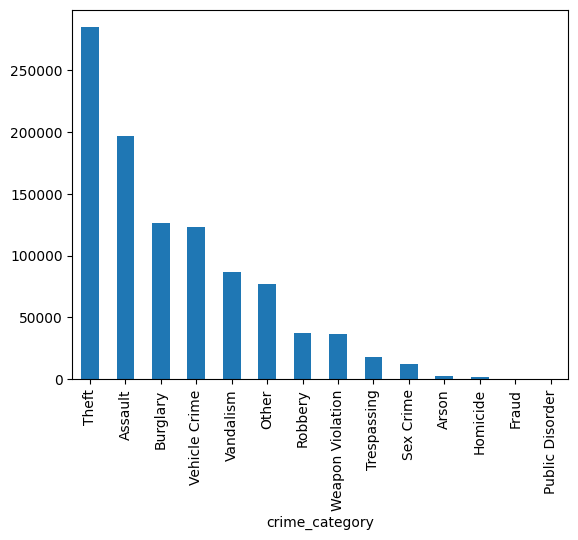

In [16]:
df['crime_category'].value_counts().plot(kind='bar')

<Axes: xlabel='hour'>

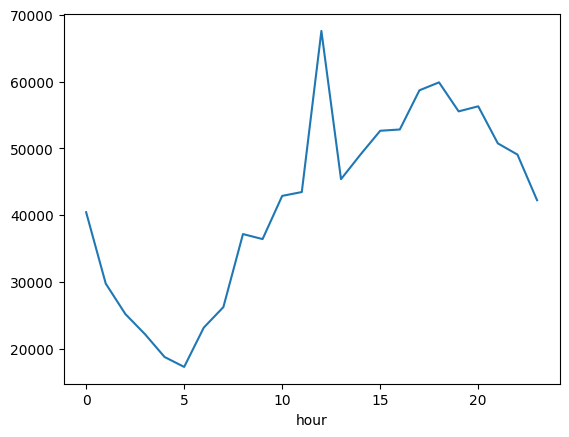

In [17]:
df.groupby('hour').size().plot()

Crime incidents peak around midday and remain elevated through the evening, with significantly lower activity during early morning hours

<Axes: xlabel='hour'>

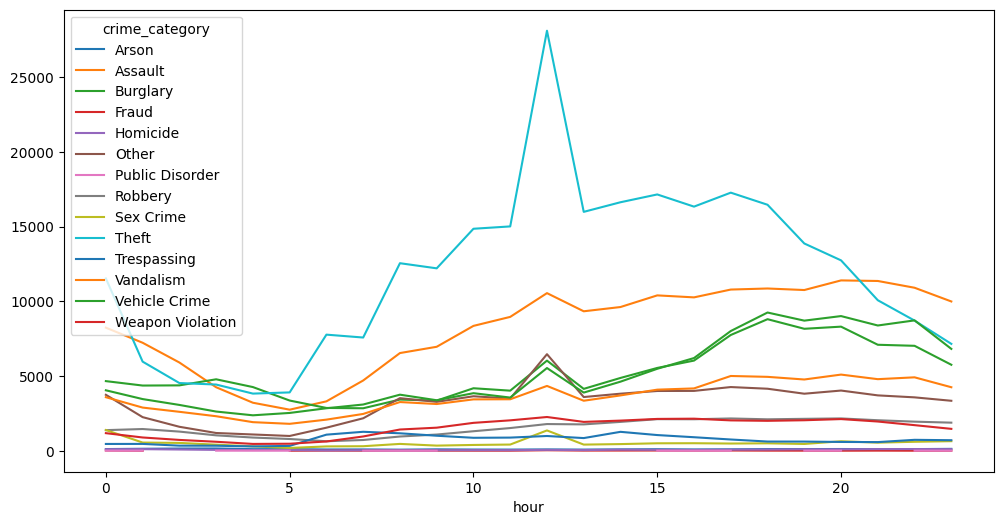

In [18]:
df.groupby(['hour', 'crime_category']).size().unstack().plot(figsize=(12,6))

Different crime types follow distinct daily patterns. Theft peaks sharply around midday, while violent crimes like assault increase later in the day and into the evening. Crime activity is lowest during early morning hours.

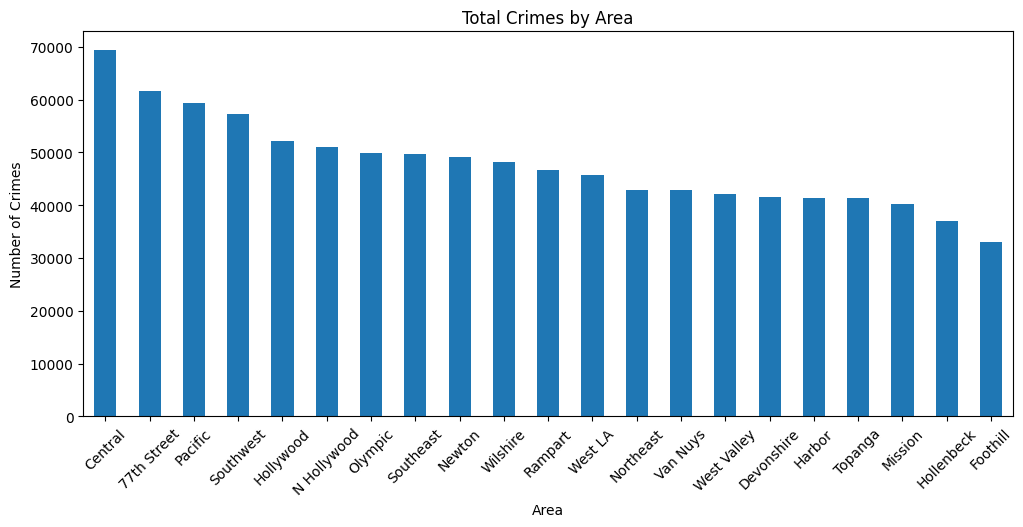

In [19]:
import matplotlib.pyplot as plt

df.groupby('area_name').size().sort_values(ascending=False).plot(
    kind='bar', figsize=(12,5)
)

plt.title("Total Crimes by Area")
plt.xlabel("Area")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()

Crime distribution varies significantly by area, with Central, 77th Street, and Pacific reporting the highest number of incidents. These areas likely reflect high population density and activity levels, emphasizing the importance of contextual factors when interpreting crime counts.

<Axes: xlabel='month'>

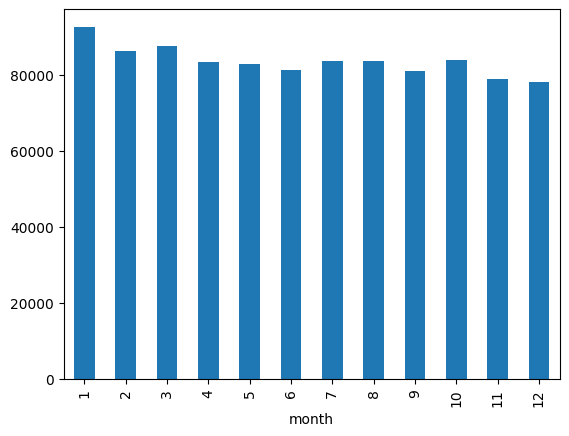

In [20]:
df['month'] = df['date_occ'].dt.month

df.groupby('month').size().plot(kind='bar')

<Axes: xlabel='date_occ'>

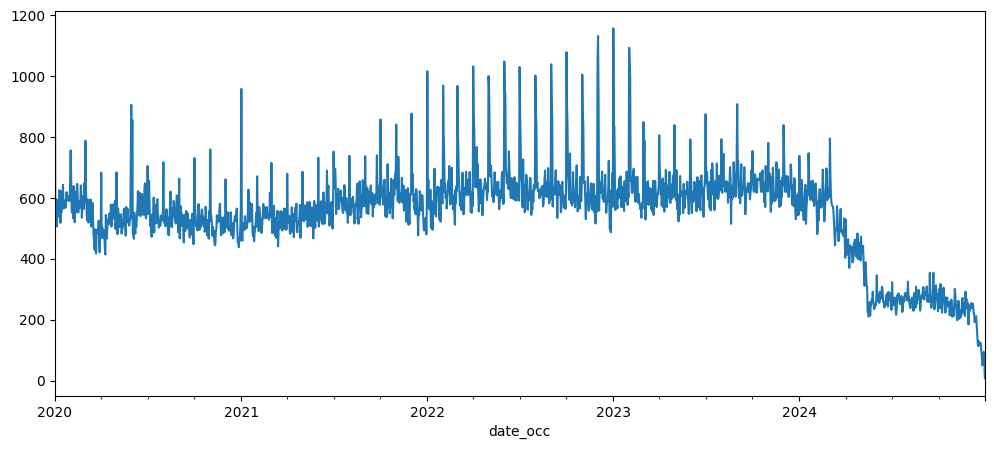

In [68]:
df.groupby('date_occ').size().plot(figsize=(12,5))